In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [22]:
 df.shape

(1000, 9)

In [23]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [24]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Initial Inspection 
There are 1000 Rows and 9 column in the detaset. There are no null values in the column .
Only Date column has the text datatype considerd , in the next step we convert it into datatime formet for the time series analysis.

In [25]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [26]:
df.mode(numeric_only=True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

## Descriptive Statistics

The average customer age is 41 years, ranging from 18 to 64 years old. The average 
transaction amount is ₹456, but the standard deviation (₹560) is quite high, showing 
that transaction values vary a lot — some purchases are as low as ₹25, while others 
go up to ₹2000. The most common Price per Unit (mode) is ₹50, suggesting that 
lower-priced items are bought more frequently, while a few high-value purchases pull 
the average amount higher.

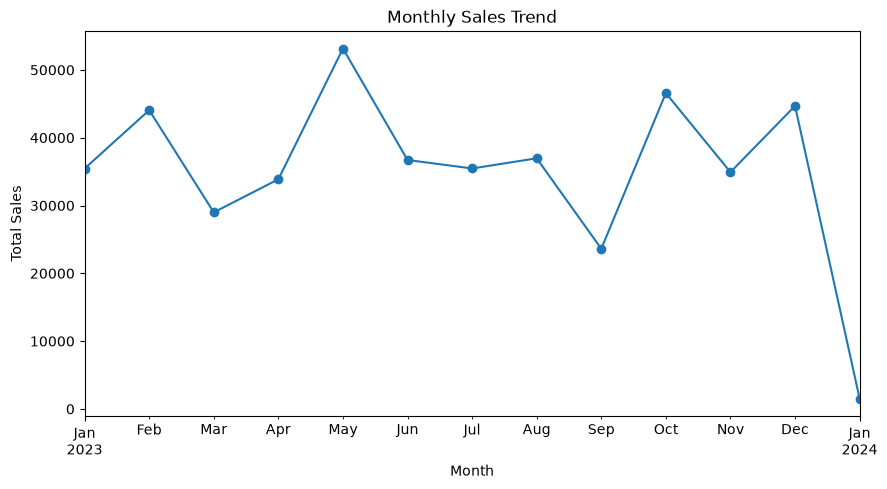

In [27]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales.plot(kind='line', figsize=(10,5), title='Monthly Sales Trend', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

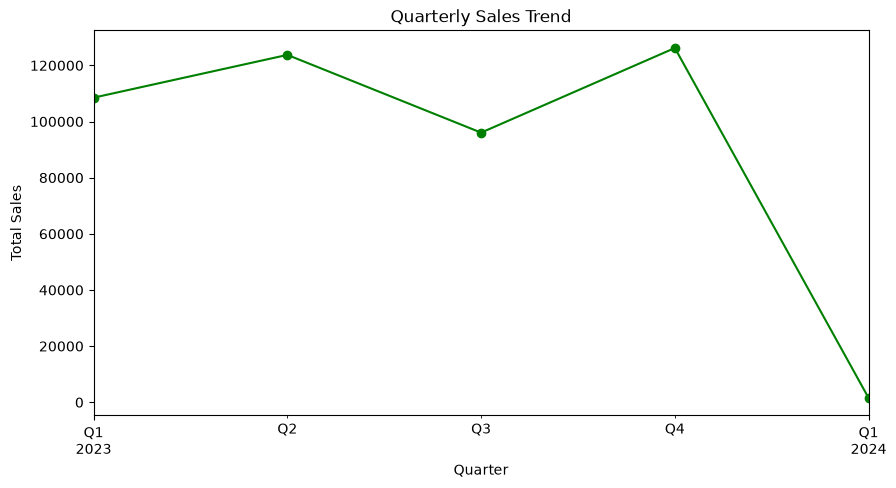

In [28]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
quarterly_sales.plot(kind='line', figsize=(10,5), title='Quarterly Sales Trend', marker='o', color='green')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()

## Time Series Analysis

Monthly sales show a lot of fluctuation throughout the year, with a clear peak in 
May 2023 (~₹52,000) and a dip in September 2023 (~₹20,000). Sales pick up again 
towards the end of the year, peaking in December 2023 (~₹44,000). At a quarterly 
level, Q2 and Q4 2023 were the strongest quarters, while Q3 was comparatively weak. 
The sharp drop shown in Jan 2024 is likely due to incomplete data for that period, 
since the dataset ends around that time, rather than an actual decline in sales.

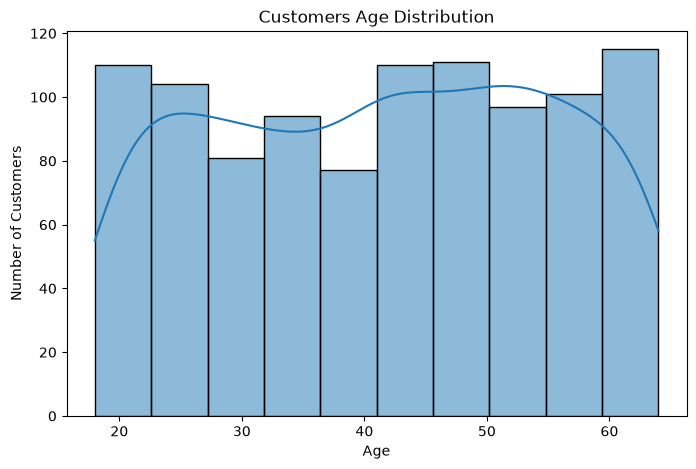

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Customers Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

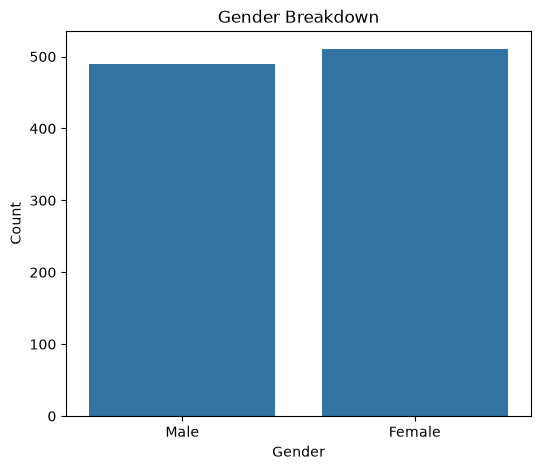

In [30]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')
plt.title('Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


## Customer Demographics Analysis

The customer base is fairly evenly distributed across age groups from 18 to 65 
years, with no single age group dominating strongly. There are slightly more 
customers in the 20-25 and 50-65 age ranges compared to the middle ages. The 
gender breakdown is almost equal, with close to 490 male and 510 female 
customers, showing that the business appeals to both genders similarly.

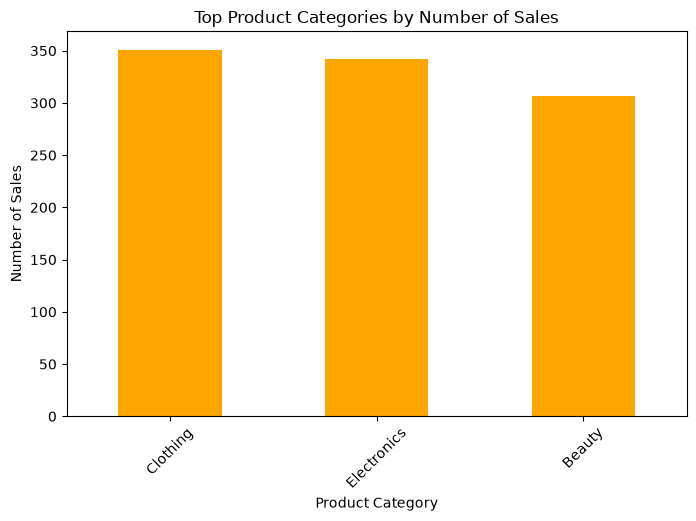

In [31]:
top_products = df['Product Category'].value_counts().head(10)
top_products.plot(kind='bar', figsize=(8,5), color='Orange', title='Top Product Categories by Number of Sales')
plt.xlabel('Product Category')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.show()

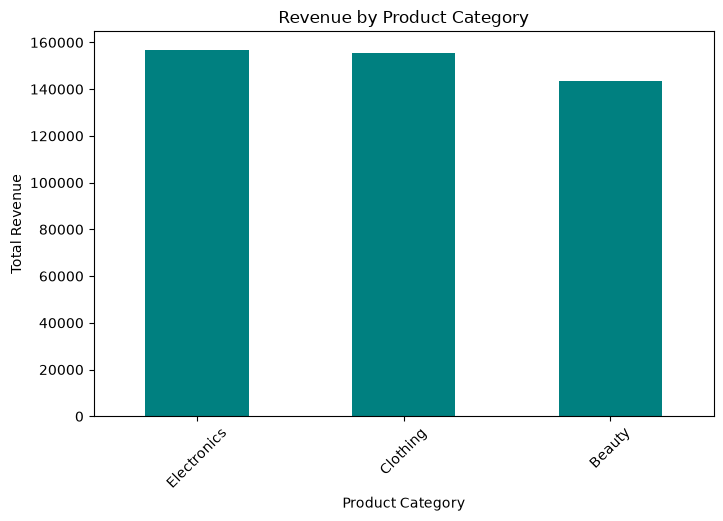

In [32]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar', figsize=(8,5), color='teal', title='Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## Product Analysis

Clothing had the most sales overall (about 350), Electronics was close behind 
(340), and Beauty had the fewest (310). But when we look at revenue, Electronics 
actually made the most money (~₹157,000) even with fewer sales than Clothing. 
This probably means Electronics items cost more per unit, so even a smaller 
number of sales adds up to bigger revenue. Beauty products brought in the least 
revenue, likely because they're cheaper items overall.

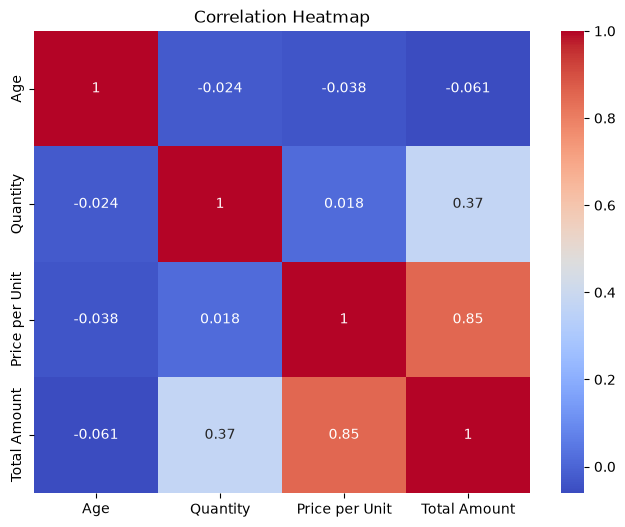

In [33]:
plt.figure(figsize=(8,6))
numeric_df = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Correlation Heatmap

Price per Unit and Total Amount are strongly related (0.85), which makes sense 
since higher-priced items naturally lead to a bigger total bill. Quantity also 
has some effect on Total Amount (0.37), but it's a weaker link compared to 
price. Age barely correlates with anything here - it doesn't seem to affect 
how much someone spends, what quantity they buy, or the price of items they 
choose.

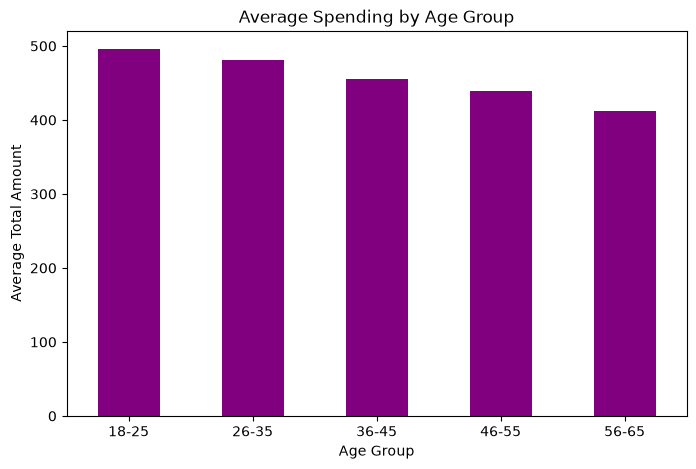

In [34]:
df['Age Group'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65], labels=['18-25','26-35','36-45','46-55','56-65'])
avg_spend = df.groupby('Age Group')['Total Amount'].mean()
avg_spend.plot(kind='bar', figsize=(8,5), color='purple')
plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=0)
plt.show()


## Extra Insight: Spending by Age Group

Interestingly, younger customers (18-25) spend the most on average per 
transaction (~₹490), and this slowly goes down as age increases, with the 
56-65 group spending the least (~₹420). This is a bit surprising since older 
customers usually have more purchasing power, but here younger customers are 
actually the bigger spenders. This could mean marketing and offers might work 
better if they focus more on the 18-35 age group.

## Conclusion & Business Recommendations

1. Target younger customers more (18-35): They spend the most per purchase, 
so ads or discounts aimed at this age group could bring in better returns.

2. Promote Electronics harder: It has fewer sales than Clothing but still 
makes the most revenue. Running offers on electronics, especially during 
busy months like May and December, could increase sales even further.

3. Handle the September slowdown: Sales dip noticeably in September every 
year. A small sale or promotion during that month could help keep revenue 
steady instead of dropping.